In [2]:
import pandas as pd

In [3]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print(train_df.shape)
print(test_df.shape)

(227452, 31)
(57355, 31)


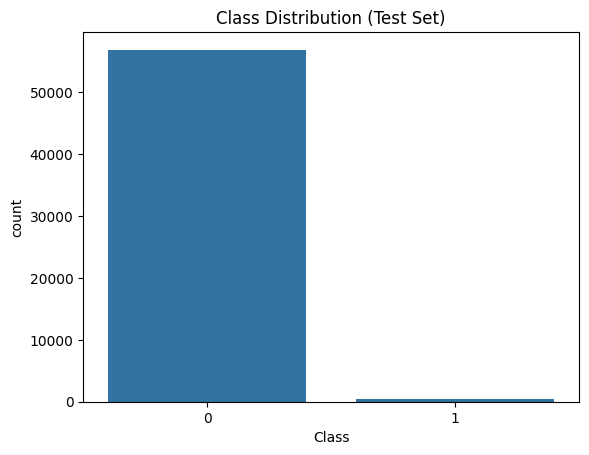

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=test_df['Class'])
plt.title("Class Distribution (Test Set)")
plt.show()

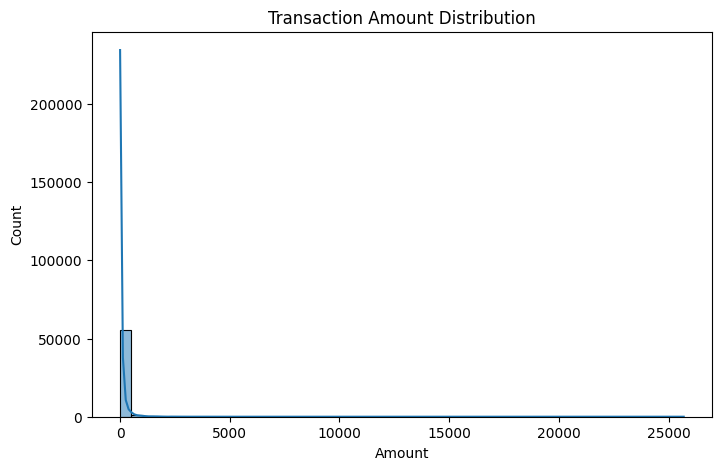

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(test_df['Amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

In [6]:
import numpy as np

train_df['Amount_log'] = np.log1p(train_df['Amount'])
test_df['Amount_log'] = np.log1p(test_df['Amount'])

In [7]:
train_df['Hour'] = (train_df['Time'] // 3600) % 24
test_df['Hour'] = (test_df['Time'] // 3600) % 24

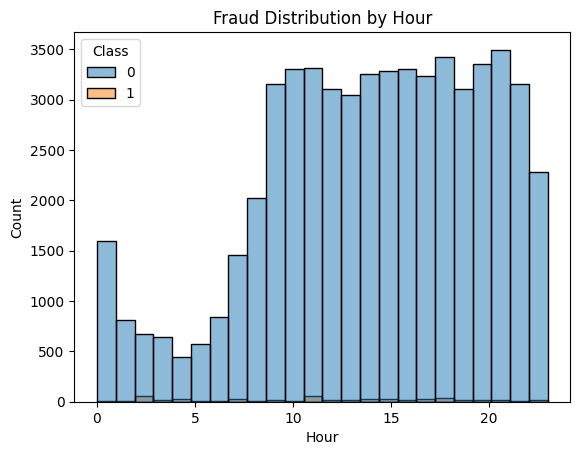

In [8]:
sns.histplot(data=test_df, x='Hour', hue='Class', bins=24)
plt.title("Fraud Distribution by Hour")
plt.show()

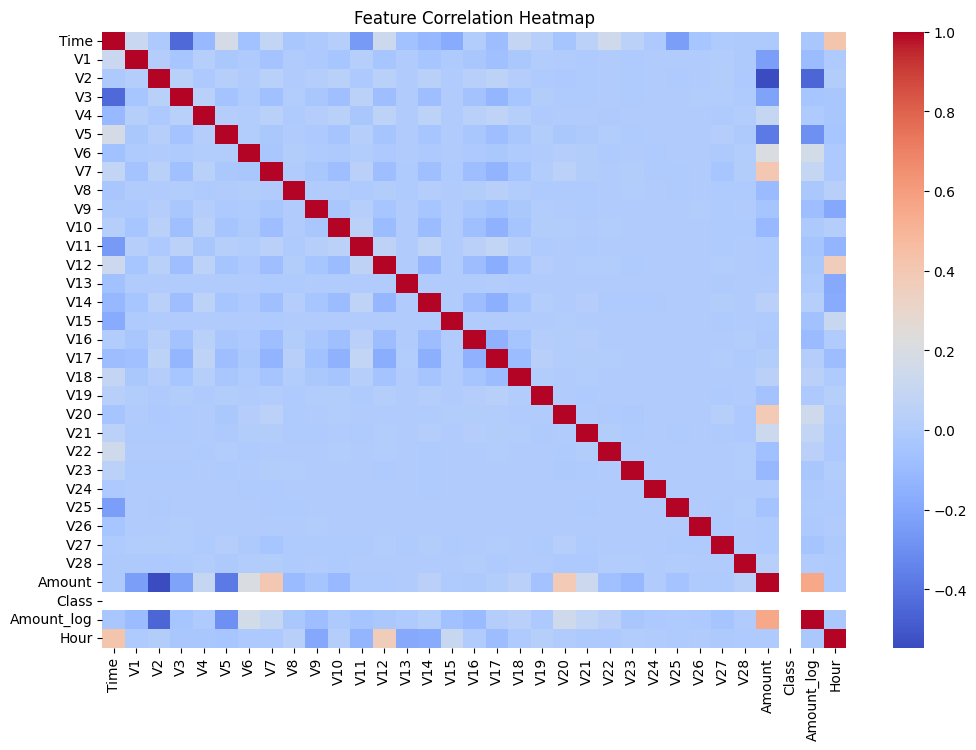

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(train_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [11]:
import sys
import os

# This adds the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.preprocessing import scale_features

train_scaled, test_scaled = scale_features(train_df, test_df)

print(train_scaled.head())

       Time        V1        V2        V3        V4        V5        V6  \
0  0.714456 -0.297006  0.186273 -0.227185 -0.130280 -0.204601 -0.054514   
1 -0.498085  0.539048  0.176112 -0.054879  0.750721  0.079634 -0.067868   
2 -0.125951  0.481049 -0.104000  0.196872  0.437046 -0.320907  0.104840   
3  0.345798  0.091603 -0.117580  0.217777 -0.778348 -0.329282 -0.201463   
4  0.931673 -0.904882 -0.820332 -0.072242 -0.652837  0.814357  1.996269   

         V7        V8        V9  ...       V23       V24       V25       V26  \
0 -0.022138  0.915184  0.578654  ...  0.580464  0.754340 -1.196667  0.884237   
1  0.142662 -0.165226 -0.102324  ... -0.605077 -0.035326  1.249620 -0.358785   
2 -0.199236  0.231690  0.160216  ...  0.307382  0.230849  0.290070  0.468206   
3  0.265152 -0.268545 -0.735534  ...  0.890087  1.389714 -0.894259  0.841576   
4  1.901424  0.609001 -0.758898  ...  1.932834 -1.213276  1.702234  1.300272   

        V27       V28    Amount  Class  Amount_log      Hour  
0 -0.

In [12]:
train_scaled.to_csv("../data/train_processed.csv", index=False)
test_scaled.to_csv("../data/test_processed.csv", index=False)

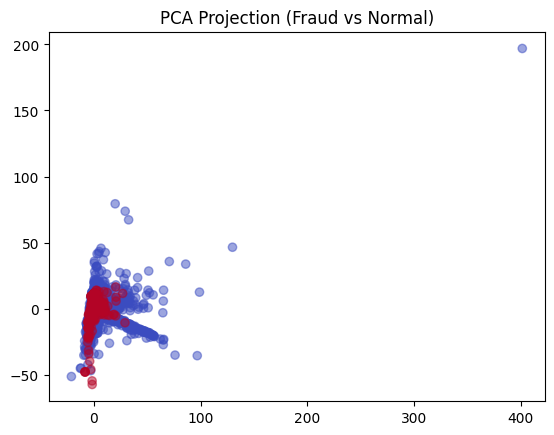

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(test_scaled.drop('Class', axis=1))

plt.scatter(pca_result[:,0], pca_result[:,1],
            c=test_scaled['Class'], cmap='coolwarm', alpha=0.5)
plt.title("PCA Projection (Fraud vs Normal)")
plt.show()

In [15]:
# 1. Train contains only normal
print("Fraud in train:", train_scaled['Class'].sum())

# 2. Check imbalance in test
print(test_scaled['Class'].value_counts(normalize=True))

# 3. Check scaling
print(train_scaled.describe().T[['mean','std']].head())

Fraud in train: 0
Class
0    0.991422
1    0.008578
Name: proportion, dtype: float64
          mean       std
Time  0.118809  0.557717
V1   -0.005459  0.864964
V2   -0.048906  1.170060
V3   -0.088712  0.763830
V4    0.008062  0.879398
